In [3]:
import tensorflow as tf
import numpy as np
import urllib.request
import os

# SketchRNN npz files hosted by Google on GCS.
# Each file contains stroke-3 format data:  (Δx, Δy, pen_lift)
CATEGORIES = ["cat", "dog", "bicycle", "airplane", "car"]
BASE_URL = "https://storage.googleapis.com/quickdraw_dataset/sketchrnn"
N_SAMPLES = 5000   # samples per category

datasets = {}
for cat in CATEGORIES:
    local_path = f"{cat}.npz"
    if not os.path.exists(local_path):
        print(f"Downloading {cat}.npz …")
        urllib.request.urlretrieve(f"{BASE_URL}/{cat}.npz", local_path)
    data = np.load(local_path, encoding="latin1", allow_pickle=True)
    # data['train'] is an object array; each element is a [T, 3] int16 array
    datasets[cat] = data["train"][:N_SAMPLES]
    print(f"Loaded {cat}: {len(datasets[cat])} samples")

print("All categories loaded.")

Loaded cat: 5000 samples
Loaded dog: 5000 samples
Loaded bicycle: 5000 samples
Loaded airplane: 5000 samples
Loaded car: 5000 samples
All categories loaded.


In [4]:
# Install dependencies (Colab)
!pip install -q tensorflow scikit-learn seaborn

In [5]:
#Preprocess the datasets

MAX_SEQ_LEN = 200   # pad/truncate all sequences to this length
NUM_CLASSES  = len(CATEGORIES)

def preprocess_np(strokes, max_len=MAX_SEQ_LEN):
    """Numpy version of preprocess — operates on raw numpy arrays."""
    strokes = strokes.astype(np.float32)
    # Normalize Δx and Δy to [-1, 1]
    strokes[:, :2] = strokes[:, :2] / 255.0
    # Truncate to max_len
    strokes = strokes[:max_len]
    # Zero-pad end if shorter than max_len
    pad_len = max_len - len(strokes)
    if pad_len > 0:
        strokes = np.pad(strokes, ((0, pad_len), (0, 0)))
    return strokes  # [max_len, 3]

def build_dataset(datasets, categories):
    all_data = []
    for idx, cat in enumerate(categories):
        # datasets[cat] is a numpy object array; each element is a [T, 3] stroke sequence
        for strokes in datasets[cat]:
            all_data.append((strokes, idx))

    xs, ys = zip(*all_data)
    xs = np.array([preprocess_np(x) for x in xs])      # [N, MAX_SEQ_LEN, 3]
    ys = np.array(ys)
    return xs, ys

# Split into train/val/test (70/15/15)
from sklearn.model_selection import train_test_split
X, y = build_dataset(datasets, CATEGORIES)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y)
X_val, X_test, y_val, y_test     = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp)
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (17500, 200, 3), Val: (3750, 200, 3), Test: (3750, 200, 3)


In [6]:
#Build the model
from tensorflow.keras import layers, models

def build_bilstm_model(num_classes, seq_len=200, features=3):
    inp = layers.Input(shape=(seq_len, features))
    x = layers.Conv1D(64, 3, padding='same', activation='relu')(inp)
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(x)
    x = layers.Bidirectional(layers.LSTM(64))(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inp, out)

In [7]:
# Compile and train

model = build_bilstm_model(NUM_CLASSES)
model.summary()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3, min_lr=1e-6),
    tf.keras.callbacks.ModelCheckpoint('best_sketch_model.keras', save_best_only=True)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=64,
    callbacks=callbacks
)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 200, 3)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 200, 64)        │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 200, 256)       │       197,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 363,269 (1.39 MB)

 Trainable params: 363,269 (1.39 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
274/274 ━━━━━━━━━━━━━━━━━━━━ 18s 41ms/step - accuracy: 0.4554 - loss: 1.2758 - val_accuracy: 0.4912 - val_loss: 1.2441 - learning_rate: 0.0010
Epoch 2/50
274/274 ━━━━━━━━━━━━━━━━━━━━ 11s 39ms/step - accuracy: 0.6219 - loss: 0.9900 - val_accuracy: 0.6661 - val_loss: 0.8644 - learning_rate: 0.0010
Epoch 3/50
274/274 ━━━━━━━━━━━━━━━━━━━━ 11s 39ms/step - accuracy: 0.7161 - loss: 0.7777 - val_accuracy: 0.7224 - val_loss: 0.7394 - learning_rate: 0.0010
Epoch 4/50
274/274 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - accuracy: 0.7711 - loss: 0.6425 - val_accuracy: 0.7803 - val_loss: 0.6265 - learning_rate: 0.0010
Epoch 5/50
274/274 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - accuracy: 0.7959 - loss: 0.5715 - val_accuracy: 0.8184 - val_loss: 0.5081 - learning_rate: 0.0010
Epoch 6/50
274/274 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - accuracy: 0.8268 - loss: 0.4932 - val_accuracy: 0.8091 - val_loss: 0.5459 - learning_rate: 0.0010
Epoch 7/50
274/274 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - accuracy: 0.8399 - l

118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9221 - loss: 0.2351
Test accuracy: 0.9221
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step
              precision    recall  f1-score   support

         cat       0.89      0.87      0.88       750
         dog       0.86      0.86      0.86       750
     bicycle       0.96      0.96      0.96       750
    airplane       0.96      0.95      0.96       750
         car       0.96      0.96      0.96       750

    accuracy                           0.92      3750
   macro avg       0.92      0.92      0.92      3750
weighted avg       0.92      0.92      0.92      3750



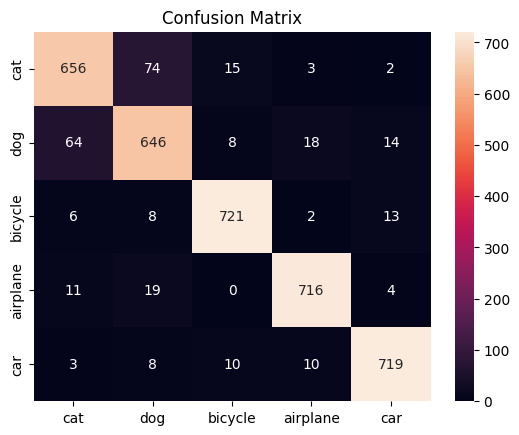

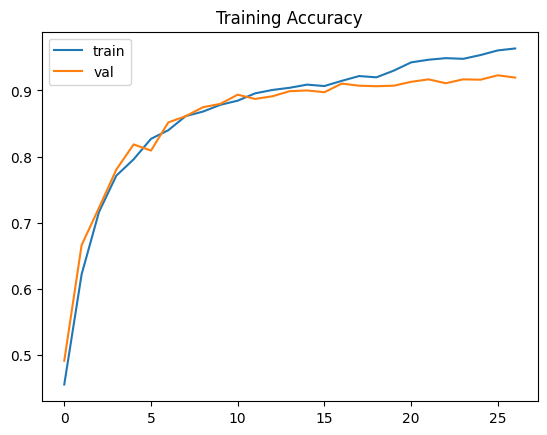

In [8]:
# Evaluate

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

y_pred = np.argmax(model.predict(X_test), axis=1)
print(classification_report(y_test, y_pred, target_names=CATEGORIES))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=CATEGORIES, yticklabels=CATEGORIES)
plt.title('Confusion Matrix')
plt.show()

# Plot training curves
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend(); plt.title('Training Accuracy'); plt.show()

In [9]:
# Predict on New Sketches

def predict_sketch(model, stroke_sequence, categories):
    # Preprocess single sample (raw numpy array, shape [T, 3])
    x = preprocess_np(stroke_sequence)          # [MAX_SEQ_LEN, 3]
    x = np.expand_dims(x, axis=0)               # [1, MAX_SEQ_LEN, 3]
    probs = model.predict(x, verbose=0)[0]
    pred_idx = np.argmax(probs)
    return categories[pred_idx], probs[pred_idx]

# Example: grab the first raw stroke sequence from the loaded dataset
new_stroke_seq = datasets[CATEGORIES[0]][0]     # shape [T, 3], raw integer strokes

label, confidence = predict_sketch(model, new_stroke_seq, CATEGORIES)
print(f"Predicted: {label} ({confidence:.1%} confidence)")

Predicted: cat (98.3% confidence)
